# Chapter 5: The Relational Data Model and Relational Database Constraints


## Teaching Summary

What does one row mean? The first-meeting selection introduces relations, tuples,
attributes, domains, and the purpose of identifiers. Read Chapters 1-2 first.
You only need to compare values and read a table; programming syntax is not a prerequisite.

Textbook: Elmasri and Navathe, *Fundamentals of Database Systems*, seventh edition,
selected opening concepts from Section 5.1. Formal keys and integrity constraints
from Sections 5.2-5.3 are the chapter's continuation, not first-meeting requirements.
This version supplies the opening selection; the continuation will be added to this
same notebook. Do not use earlier-book notebook numbers as assigned reading.

You should be able to identify a complete tuple and an attribute value, distinguish
the domain from observed values, compare repeated values with duplicate tuples,
and explain why a person's name may not identify one student.


## 1. Read One Student Table

In the relational model, a **relation** is a set of tuples. A **tuple** is one complete
row of values; an **attribute** names a position or role in its schema. We display
relations as tables, but an unrestricted SQL table can allow duplicate rows and is
not automatically a mathematical set.

The schema here is `student(student_id, email, student_name, dept_code)`. Each row
describes one student, not one enrollment. IM means Information Management, FIN means
Finance, and DES means Digital Design. These are synthetic records, not personal data.

| student_id | email | student_name | dept_code |
|---|---|---|---|
| S101 | an@example.test | An Chen | IM |
| S102 | bea@example.test | Bea Lin | FIN |
| S103 | kai@example.test | Kai Wu | IM |
| S104 | mira@example.test | Mira Ho | DES |

**Predict:** How many tuples and attributes are shown? Write S103's complete tuple,
then name the attribute whose value is `IM`. Do not count the header as a student.


### Read the complete tuple and one attribute value

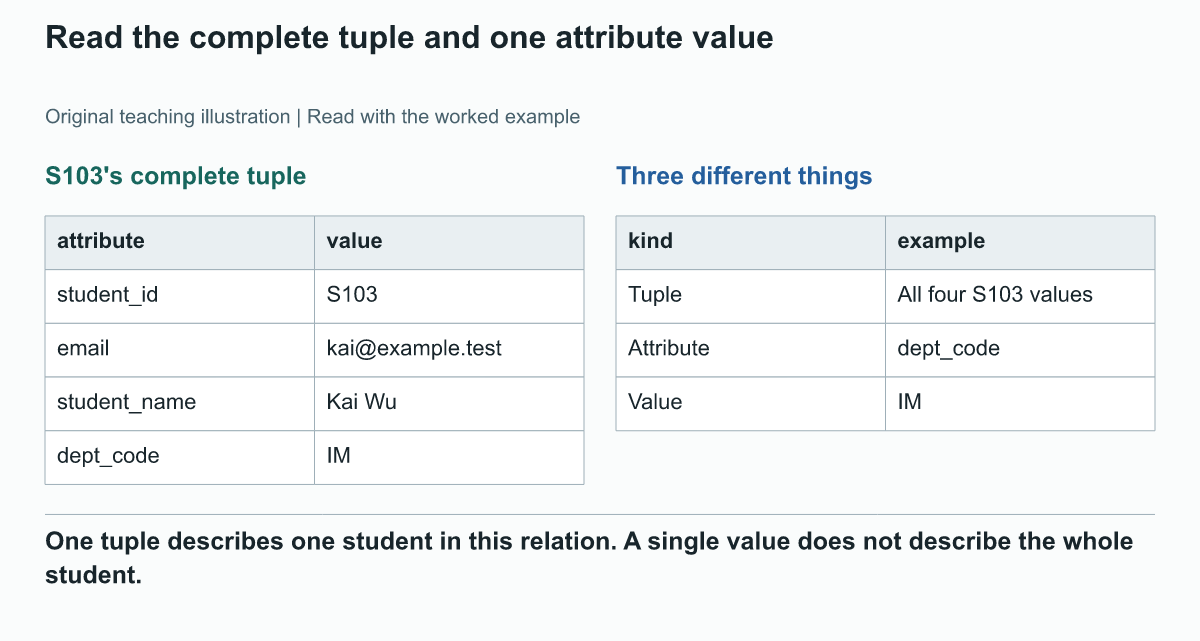

One tuple describes one student in this relation. A single value does not describe the whole student.


### Read the Diagram

There are four tuples and four attributes. S103's tuple contains its ID, email, name,
and department. `dept_code` is an attribute; `IM` is a value. A single value does not
describe the whole student. Repeating IM in two rows does not make those rows identical.


### Observe the Table

Run each example independently: it creates its own inputs in memory and closes its
connection. The Python example below creates and prints the supplied table. You are
not expected to recreate the code. Predict the tuple and attribute counts before running.


In [1]:
import sqlite3

db = sqlite3.connect(":memory:")
try:
    db.execute("CREATE TABLE student (student_id TEXT NOT NULL PRIMARY KEY, email TEXT, student_name TEXT, dept_code TEXT)")
    db.executemany("INSERT INTO student VALUES (?, ?, ?, ?)", [
        ("S101", "an@example.test", "An Chen", "IM"),
        ("S102", "bea@example.test", "Bea Lin", "FIN"),
        ("S103", "kai@example.test", "Kai Wu", "IM"),
        ("S104", "mira@example.test", "Mira Ho", "DES"),
    ])
    cursor = db.execute("SELECT * FROM student ORDER BY student_id")
    rows = cursor.fetchall()
    print(" | ".join(column[0] for column in cursor.description))
    for row in rows:
        print(" | ".join(row))
    print(f"Tuples: {len(rows)}; attributes: {len(cursor.description)}")
finally:
    db.close()


student_id | email | student_name | dept_code
S101 | an@example.test | An Chen | IM
S102 | bea@example.test | Bea Lin | FIN
S103 | kai@example.test | Kai Wu | IM
S104 | mira@example.test | Mira Ho | DES
Tuples: 4; attributes: 4


The output preserves all four values for each student. Its 16 displayed attribute
values are not 16 students. The supplied key declaration protects identifiers;
its syntax and formal key classification are not required in this first meeting.

**Practice:** Write S102's complete tuple and S104's department value. Check your tuple
against all four attribute names. Explain why these two requested answers have
different sizes.


## 2. A Domain Is More Than This Sample

A **domain** specifies possible atomic values, not just the values already present.
For a simplified course rule, suppose credits must be a whole number from 1 to 6.
The table currently contains 2 and 3, but 5 is also permitted by that rule.
The value 2.5 is not permitted even though it lies between the numeric endpoints.

**Predict:** Which of 5, 2.5, and 7 satisfies the stated domain? Which of those values
has already appeared in the sample? These are different questions.


### Allowed credits: whole numbers 1 through 6

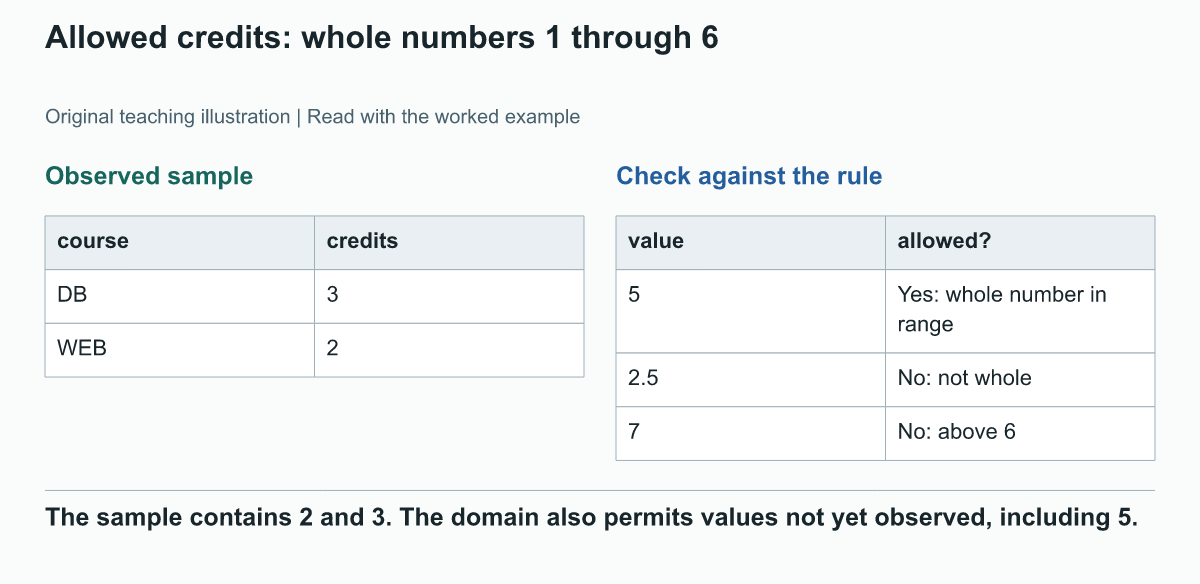

The sample contains 2 and 3. The domain also permits values not yet observed, including 5.


### Read the Diagram

Only 5 satisfies the whole-number rule. The sample is not an exhaustive list of
possible values: absence alone does not imply a domain violation. A database must
actually enforce the intended rule; a label such as INTEGER does not by itself prove
whole-number enforcement in every DBMS.

**Practice:** Define a domain for a room's seating capacity, including the allowed
numeric kind and bounds. Supply one permitted value missing from a two-row sample
and one rejected value. Check each against your stated rule, not your sample alone.


## 3. One Phone Value at a Time

In the basic relational model, attribute values are **atomic** within that model.
A multivalued attribute is represented separately rather than as a set inside one
attribute value. Atomicity is about the chosen representation, not whether a text
string can physically be split into characters.

Suppose S101 has two phone numbers. If the task is to find students by an individual
phone number, representing one student/phone pair per row makes that question explicit.
The schema becomes `student_phone(student_id, phone_number)`, where each tuple now
describes one association, not all information about one student.

**Predict:** How many phone rows represent S101's two numbers and S102's one number?
Does repeating S101 in two phone rows necessarily duplicate a complete tuple?


### A row can describe a student-phone association

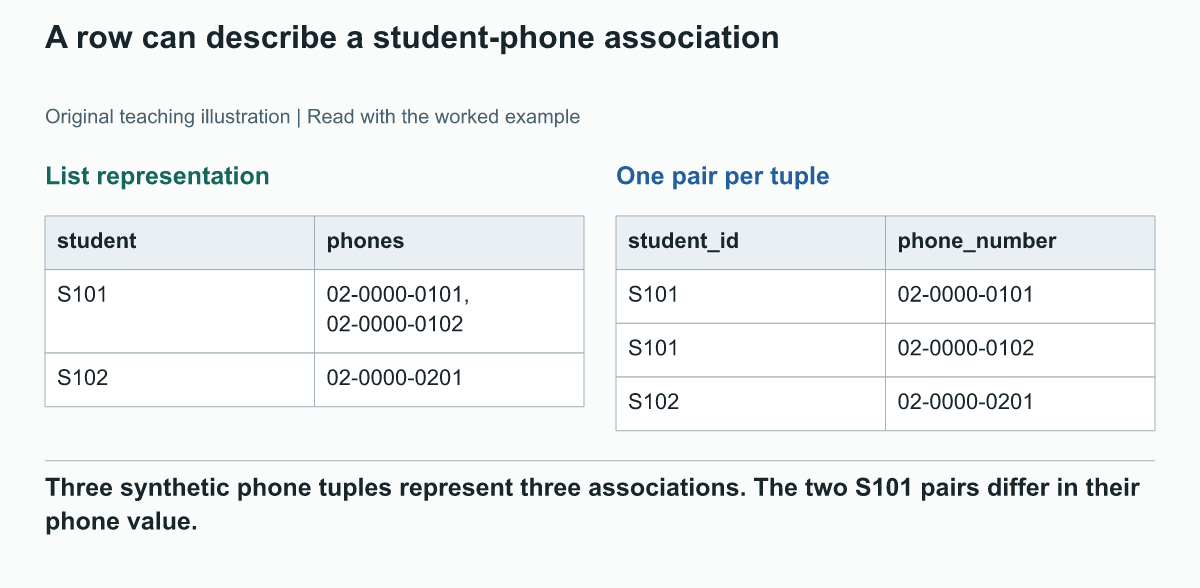

Three synthetic phone tuples represent three associations. The two S101 pairs differ in their phone value.


### Read the Diagram

There are three phone tuples. S101 repeats, but the two phone values differ, so the
complete pairs are distinct. This does not imply that one student must have one row
in every relation: row meaning depends on the relation's schema.

**Practice:** Add a second phone for S102 on paper. State the new tuple and row count.
Then identify the exact pair that would be a duplicate if inserted twice. Full ER
mapping and normalization rules are taught later; no 1NF test is required here.


## 4. Display Order and Repeated Values

A relation is a set, so its tuple order is not part of its logical meaning. A table
display still has an order. Sorting a display can change which row appears first
without changing the represented facts. Keep attribute names attached to their values:
exchanging a name and an email would change the tuple, not merely its display order.

**Predict:** If S101, S102, and S103 are displayed in reverse ID order, is a student
added or removed? If only their department values are displayed, how many copies
of IM appear before duplicates are removed?


### Same student facts, different display orders

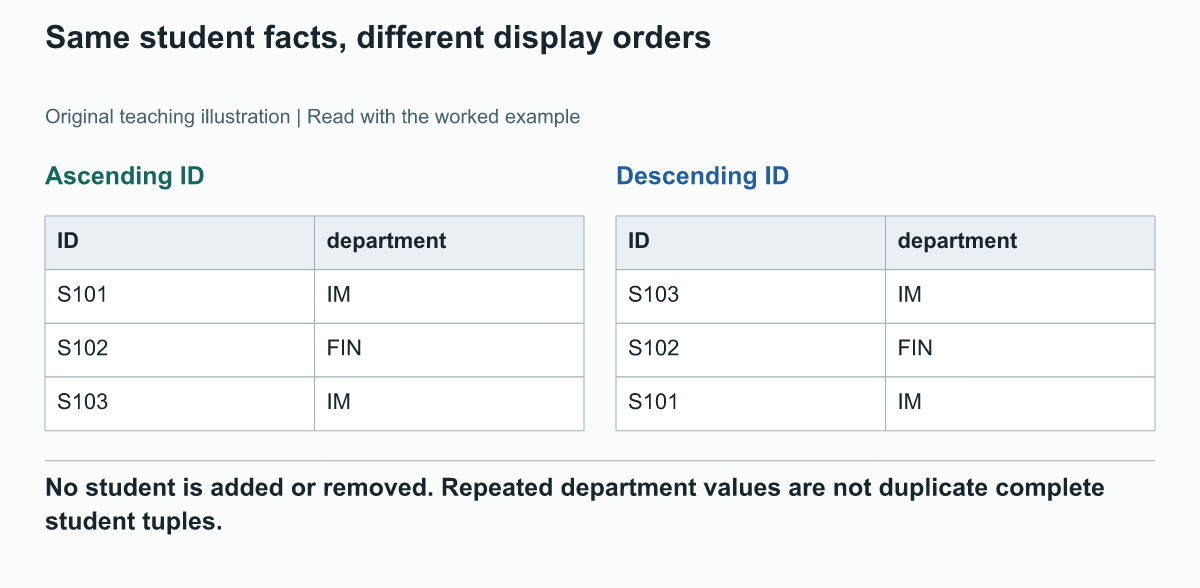

No student is added or removed. Repeated department values are not duplicate complete student tuples.


### Read the Diagram

The reversed display contains the same three student/department pairs. The department
list contains IM, FIN, IM. A set of departments contains only IM and FIN.
SQL normally retains duplicate result rows unless the query requests otherwise.


### Observe Repetition and Deduplication

Predict all four outputs, including the final stored row count. Each query below
reads the same three stored rows.


In [2]:
import sqlite3

db = sqlite3.connect(":memory:")
try:
    db.execute("CREATE TABLE student (student_id TEXT NOT NULL PRIMARY KEY, dept_code TEXT)")
    db.executemany("INSERT INTO student VALUES (?, ?)", [("S101", "IM"), ("S102", "FIN"), ("S103", "IM")])
    print("Reversed IDs:", db.execute("SELECT student_id FROM student ORDER BY student_id DESC").fetchall())
    print("Department result:", db.execute("SELECT dept_code FROM student ORDER BY student_id").fetchall())
    print("Distinct departments:", db.execute("SELECT DISTINCT dept_code FROM student ORDER BY dept_code").fetchall())
    print("Stored students:", db.execute("SELECT COUNT(*) FROM student").fetchone()[0])
finally:
    db.close()


Reversed IDs: [('S103',), ('S102',), ('S101',)]
Department result: [('IM',), ('FIN',), ('IM',)]
Distinct departments: [('FIN',), ('IM',)]
Stored students: 3


DISTINCT returns two department rows, but the stored table still has three students.
It did not delete one of the students in IM. SQL syntax is supplied here to let you
check the distinction; writing these queries is a later learning objective.

**Practice:** Add S104 in DES on paper. Predict the stored student count and the
distinct department count. Check separately whether you added a student and whether
you introduced a department value not previously present.


## 5. Why Identifiers Matter

A person's name may be shared by different people. Suppose the office has verified
that S103 and S105 are different students, both called Kai Wu. Their names alone
cannot choose the correct row. The case assigns each student a stable, distinct ID.
That is a business rule, not something established just by seeing unique values in
a small sample.

**Predict:** If an instruction says only "change Kai Wu's department," how many rows
could it refer to? Which additional value identifies S105 under the stated rule?


### One name can match two different students

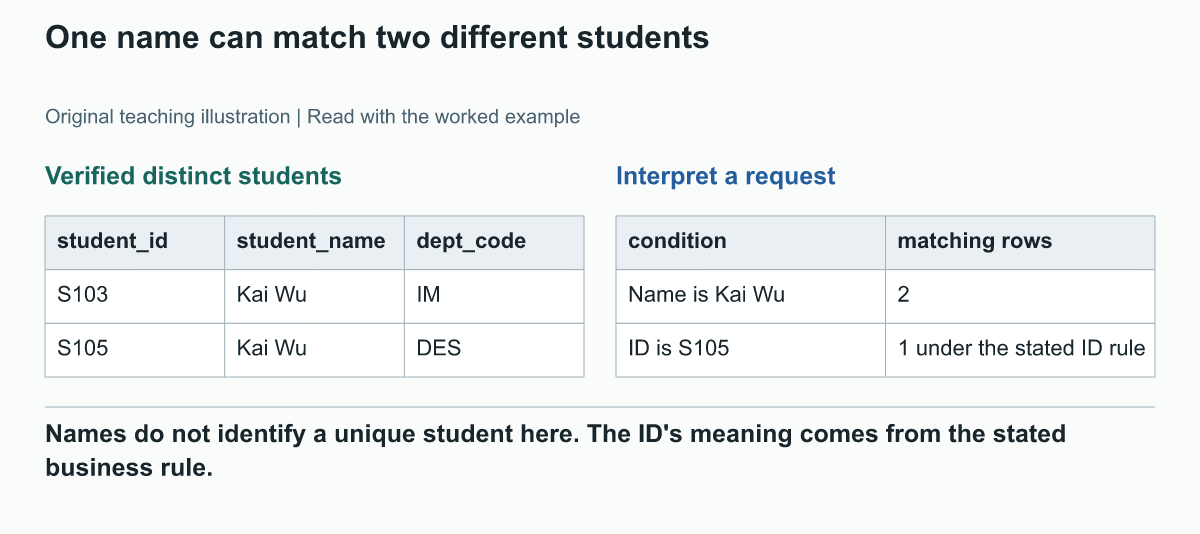

Names do not identify a unique student here. The ID's meaning comes from the stated business rule.


### Read the Diagram

The name matches two students. S105 identifies the second one under the rule.
Adding a random attribute does not automatically create a reliable identifier;
the rule must establish how it distinguishes permitted records.

**Practice:** Explain why a newly observed student with an unused name would not
prove that names are always unique. Use the two Kai Wu rows as a counterexample.
Candidate, primary, composite, and foreign key definitions are for the continuation.


## First-Meeting Summary and Practice

One tuple expresses one fact appropriate to its relation. Attributes give values
their roles; domains constrain possible values. Repeated values differ from repeated
complete tuples. Display order differs from stored facts. Identifiers require rules.

| Question | Your response | Evidence to check |
|---|---|---|
| What is S103's complete tuple in the first table? | | All four named attributes |
| Can an allowed domain value be absent from the sample? | | Rule and a concrete value |
| Did DISTINCT remove a stored student? | | Final stored row count |
| Why is a name insufficient in the last example? | | Two distinct IDs with the same name |

Keep one prediction, the observed result, and either your correction or an explanation
of why your prediction was correct. Questions support classroom discussion and review;
only instructor-assigned submissions are graded.

**Stop here for the first meeting.** The continuation of this chapter will cover
formal keys, entity integrity, referential integrity, and constraint violations.
Chapter 8 then expresses queries as relational-algebra operations. Neither continuation
is an extra task to finish before the next class unless explicitly assigned.
